In [1]:
import pandas as pd
import numpy as np

from IPython.display import display

# Load survival dataset
file_path = "../data/processed/survival_dataset.csv"

survival_df = pd.read_csv(file_path)

print("Dataset shape:", survival_df.shape)

display(survival_df.head())

Dataset shape: (50000, 5)


,customer_id,duration_days,duration_years,event,annual_premium
0,2.213007e+11,16,0.043806,1,756.722144
1,2.213033e+11,4828,13.218344,0,875.814547
2,2.213023e+11,1751,4.793977,0,654.552197
3,2.213030e+11,2230,6.105407,0,795.654884
4,2.213006e+11,159,0.435318,1,1142.303520


In [2]:
# Target variable
y = survival_df["event"]

# Remove identifiers and target-related columns
X = survival_df.drop(
    columns=["customer_id", "duration_days", "duration_years", "event"]
)

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

display(X.head())

Feature shape: (50000, 1)
Target shape: (50000,)


,annual_premium
0,756.722144
1,875.814547
2,654.552197
3,795.654884
4,1142.303520


In [3]:
# Load the original dataset containing customer features
original_df = pd.read_csv("../data/processed/eda_dataset.csv")

print("Original dataset shape:", original_df.shape)

display(original_df.head())

Original dataset shape: (50000, 16)


,customer_id,starting_date,suspension_date,observation_end_date,duration_days,event,age,income,annual_premium,has_children,marital_status,home_owner,college_degree,good_credit,county,duration_years
0,2.213007e+11,2022-09-02,2022-09-18,2022-09-18,16,1,42.806,250000.0,756.722144,1.0,Married,1.0,0.0,1.0,Tarrant,0.043806
1,2.213033e+11,2009-09-13,NaN,2022-12-02,4828,0,47.305,125000.0,875.814547,0.0,Married,1.0,1.0,1.0,Tarrant,13.218344
2,2.213023e+11,2018-02-15,NaN,2022-12-02,1751,0,41.892,70000.0,654.552197,1.0,Single,1.0,1.0,1.0,Collin,4.793977
3,2.213030e+11,2016-10-24,NaN,2022-12-02,2230,0,58.639,42500.0,795.654884,0.0,Single,1.0,0.0,1.0,Tarrant,6.105407
4,2.213006e+11,2022-06-24,2022-11-30,2022-11-30,159,1,55.444,125000.0,1142.303520,0.0,Unknown,0.0,0.0,1.0,Denton,0.435318


In [4]:
# Select required columns from the original dataset
feature_columns = [
    "customer_id",
    "age",
    "income",
    "annual_premium",
    "has_children",
    "marital_status",
    "home_owner",
    "college_degree",
    "good_credit",
    "county"
]

features_df = original_df[feature_columns].copy()

# Merge features with survival target
model_df = features_df.merge(
    survival_df[[
        "customer_id",
        "duration_days",
        "duration_years",
        "event"
    ]],
    on="customer_id",
    how="inner"
)

print("Merged dataset shape:", model_df.shape)

display(model_df.head())

Merged dataset shape: (50000, 13)


,customer_id,age,income,annual_premium,has_children,marital_status,home_owner,college_degree,good_credit,county,duration_days,duration_years,event
0,2.213007e+11,42.806,250000.0,756.722144,1.0,Married,1.0,0.0,1.0,Tarrant,16,0.043806,1
1,2.213033e+11,47.305,125000.0,875.814547,0.0,Married,1.0,1.0,1.0,Tarrant,4828,13.218344,0
2,2.213023e+11,41.892,70000.0,654.552197,1.0,Single,1.0,1.0,1.0,Collin,1751,4.793977,0
3,2.213030e+11,58.639,42500.0,795.654884,0.0,Single,1.0,0.0,1.0,Tarrant,2230,6.105407,0
4,2.213006e+11,55.444,125000.0,1142.303520,0.0,Unknown,0.0,0.0,1.0,Denton,159,0.435318,1


In [5]:
print(model_df.columns.tolist())
print(model_df.isnull().sum())

['customer_id', 'age', 'income', 'annual_premium', 'has_children', 'marital_status', 'home_owner', 'college_degree', 'good_credit', 'county', 'duration_days', 'duration_years', 'event']
customer_id          0
age               3670
income            3670
annual_premium       0
has_children      3670
marital_status       0
home_owner        3670
college_degree    3670
good_credit       3670
county               0
duration_days        0
duration_years       0
event                0
dtype: int64


In [6]:
from sklearn.model_selection import train_test_split

# Features
X = model_df.drop(
    columns=[
        "customer_id",
        "duration_days",
        "duration_years",
        "event"
    ]
)

# Target
y = model_df["event"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (35000, 9)
X_test: (15000, 9)
y_train: (35000,)
y_test: (15000,)


In [7]:
categorical_columns = [
    "marital_status",
    "county"
]

In [8]:
categorical_columns = [
    "marital_status",
    "county"
]

In [9]:
numerical_columns = [
    "age",
    "income",
    "annual_premium",
    "has_children",
    "home_owner",
    "college_degree",
    "good_credit"
]

In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Numerical preprocessing
numerical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

# Categorical preprocessing
categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

# Combined preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("numerical", numerical_pipeline, numerical_columns),
        ("categorical", categorical_pipeline, categorical_columns)
    ]
)

print("Preprocessor created successfully.")

Preprocessor created successfully.


In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

In [12]:
# Create Logistic Regression pipeline
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

# Train the model
logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [13]:
# Predict event classes
y_pred = logistic_model.predict(X_test)

# Predict probability of event = 1
y_probability = logistic_model.predict_proba(X_test)[:, 1]

print("Predictions generated successfully.")

print("Prediction shape:", y_pred.shape)
print("Probability shape:", y_probability.shape)

Predictions generated successfully.
Prediction shape: (15000,)
Probability shape: (15000,)


In [14]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

roc_auc = roc_auc_score(
    y_test,
    y_probability
)

print("Logistic Regression Results")
print("-" * 35)
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    zero_division=0
))

Logistic Regression Results
-----------------------------------
Accuracy : 0.5094
Precision: 0.0816
Recall   : 0.4741
F1 Score : 0.1392
ROC-AUC  : 0.4920

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.51      0.66     13745
           1       0.08      0.47      0.14      1255

    accuracy                           0.51     15000
   macro avg       0.50      0.49      0.40     15000
weighted avg       0.84      0.51      0.61     15000



Confusion Matrix:
[[7046 6699]
 [ 660  595]]


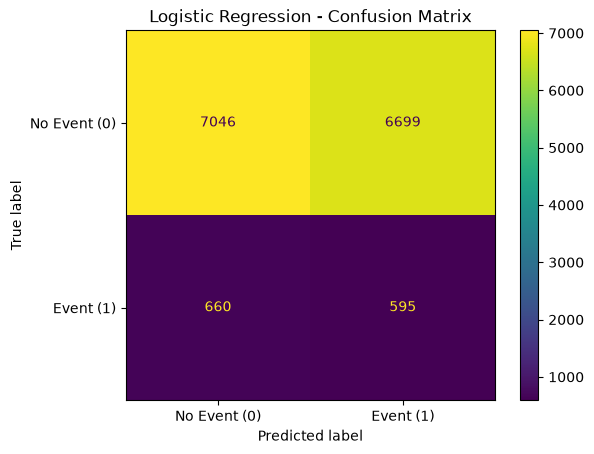

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Event (0)", "Event (1)"]
)

disp.plot()
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

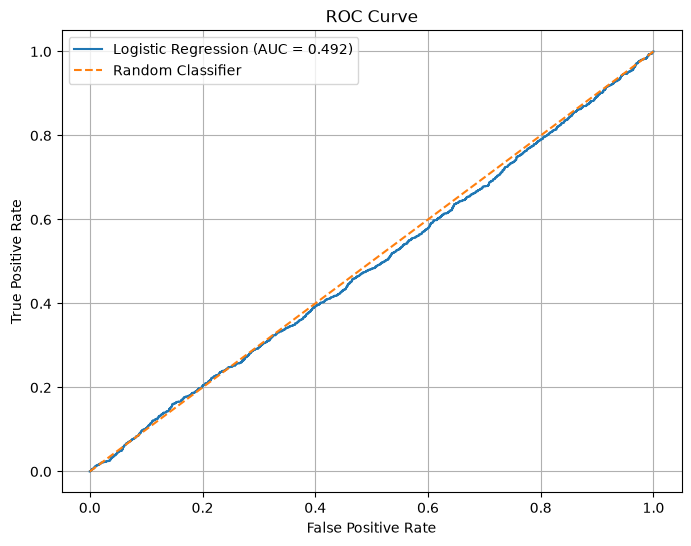

In [16]:
from sklearn.metrics import roc_curve, auc

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_probability
)

roc_auc_value = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {roc_auc_value:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.show()

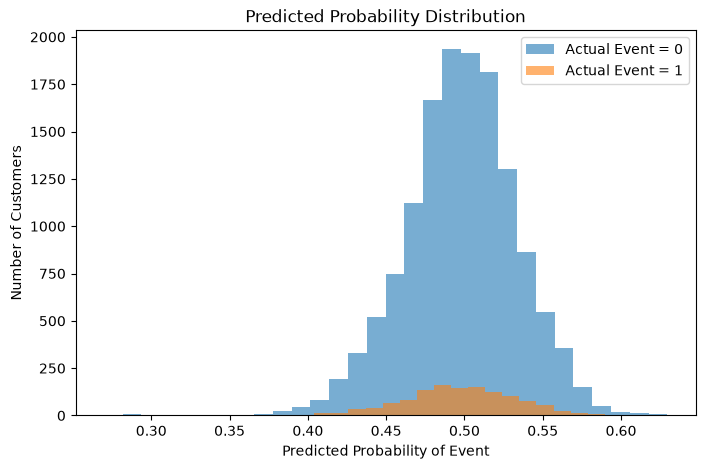

In [17]:
plt.figure(figsize=(8, 5))

plt.hist(
    y_probability[y_test.to_numpy() == 0],
    bins=30,
    alpha=0.6,
    label="Actual Event = 0"
)

plt.hist(
    y_probability[y_test.to_numpy() == 1],
    bins=30,
    alpha=0.6,
    label="Actual Event = 1"
)

plt.xlabel("Predicted Probability of Event")
plt.ylabel("Number of Customers")
plt.title("Predicted Probability Distribution")
plt.legend()
plt.show()

In [18]:
import os
import joblib

# Create model directory if it does not exist
os.makedirs("../models_saved", exist_ok=True)

# Save Logistic Regression pipeline
model_path = "../models_saved/logistic_model.pkl"

joblib.dump(
    logistic_model,
    model_path
)

print("Model saved successfully:", model_path)

Model saved successfully: ../models_saved/logistic_model.pkl


In [19]:
import os
import joblib

# Create model directory if it does not exist
os.makedirs("../models_saved", exist_ok=True)

# Save Logistic Regression pipeline
model_path = "../models_saved/logistic_model.pkl"

joblib.dump(
    logistic_model,
    model_path
)

print("Model saved successfully:", model_path)

Model saved successfully: ../models_saved/logistic_model.pkl


# Corrected Cox Proportional Hazards Modeling

**Important:** `duration_years` is the survival time and `event` is the event indicator.  
Neither `duration_days` nor `duration_years` must be used as predictor features. Including survival duration as a feature causes target leakage.

In [20]:
# Prepare Cox modeling data without target leakage

from lifelines import CoxPHFitter
from lifelines.utils import concordance_index
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import pandas as pd
import numpy as np

# Keep predictors, survival duration, and event separately
cox_base = model_df.copy()

cox_features = [
    "age",
    "income",
    "annual_premium",
    "has_children",
    "home_owner",
    "college_degree",
    "good_credit",
    "marital_status",
    "county"
]

cox_base["duration_years"] = pd.to_numeric(
    cox_base["duration_years"], errors="coerce"
)
cox_base["event"] = pd.to_numeric(
    cox_base["event"], errors="coerce"
)

# Do not impute survival time or event indicator
cox_base = cox_base.dropna(
    subset=["duration_years", "event"]
).copy()

# Validate survival target
cox_base = cox_base[
    (cox_base["duration_years"] > 0) &
    (cox_base["event"].isin([0, 1]))
].copy()

cox_train, cox_test = train_test_split(
    cox_base,
    test_size=0.30,
    random_state=42,
    stratify=cox_base["event"]
)

print("Cox train shape:", cox_train.shape)
print("Cox test shape:", cox_test.shape)
print("Train event distribution:")
print(cox_train["event"].value_counts(normalize=True))
print("Test event distribution:")
print(cox_test["event"].value_counts(normalize=True))


Cox train shape: (35000, 13)
Cox test shape: (15000, 13)
Train event distribution:
event
0    0.916314
1    0.083686
Name: proportion, dtype: float64
Test event distribution:
event
0    0.916333
1    0.083667
Name: proportion, dtype: float64


In [21]:
# Fit preprocessing on training data only

cox_numeric = [
    "age",
    "income",
    "annual_premium",
    "has_children",
    "home_owner",
    "college_degree",
    "good_credit"
]

cox_categorical = [
    "marital_status",
    "county"
]

cox_numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

cox_categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

cox_preprocessor = ColumnTransformer(
    transformers=[
        ("num", cox_numeric_pipeline, cox_numeric),
        ("cat", cox_categorical_pipeline, cox_categorical)
    ]
)

X_cox_train = cox_preprocessor.fit_transform(
    cox_train[cox_features]
)
X_cox_test = cox_preprocessor.transform(
    cox_test[cox_features]
)

cox_feature_names = cox_preprocessor.get_feature_names_out()

X_cox_train_df = pd.DataFrame(
    X_cox_train,
    columns=cox_feature_names,
    index=cox_train.index
)

X_cox_test_df = pd.DataFrame(
    X_cox_test,
    columns=cox_feature_names,
    index=cox_test.index
)

cox_train_ready = X_cox_train_df.copy()
cox_train_ready["duration_years"] = cox_train["duration_years"]
cox_train_ready["event"] = cox_train["event"]

cox_test_ready = X_cox_test_df.copy()
cox_test_ready["duration_years"] = cox_test["duration_years"]
cox_test_ready["event"] = cox_test["event"]

print("Prepared Cox train shape:", cox_train_ready.shape)
print("Prepared Cox test shape:", cox_test_ready.shape)
print("Missing values in Cox train:", cox_train_ready.isna().sum().sum())


Prepared Cox train shape: (35000, 27)
Prepared Cox test shape: (15000, 27)
Missing values in Cox train: 0


In [22]:
# Train corrected Cox Proportional Hazards model

cox_model = CoxPHFitter(
    penalizer=0.10,
    l1_ratio=0.0
)

cox_model.fit(
    cox_train_ready,
    duration_col="duration_years",
    event_col="event"
)

print("Corrected Cox model trained successfully.")
display(cox_model.summary)


d:\Insurance_Lapse_CLV\Insurance_Lapse_CLV\.venv\Lib\site-packages\lifelines\utils\__init__.py:1100: ConvergenceWarning: Column(s) ['cat__county_Hill'] have very low variance. This may harm convergence. 1) Are you using formula's? Did you mean to add '-1' to the end. 2) Try dropping this redundant column before fitting if convergence fails.

  warnings.warn(dedent(warning_text), ConvergenceWarning)


Corrected Cox model trained successfully.


,coef,exp(coef),se(coef),coef lower 95%,coef upper 95%,exp(coef) lower 95%,exp(coef) upper 95%,cmp to,z,p,-log2(p)
covariate,,,,,,,,,,,
num__age,-0.123279,0.884017,0.012865,-0.148493,-0.098065,0.862006,0.906590,0.0,-9.582872,9.438280e-22,69.843894
num__income,-0.025184,0.975130,0.012724,-0.050123,-0.000246,0.951113,0.999754,0.0,-1.979329,4.777897e-02,4.387480
num__annual_premium,-0.005575,0.994440,0.012528,-0.030130,0.018980,0.970319,1.019161,0.0,-0.445031,6.562977e-01,0.607578
num__has_children,0.013715,1.013809,0.012829,-0.011430,0.038859,0.988635,1.039624,0.0,1.069050,2.850473e-01,1.810727
num__home_owner,-0.026736,0.973618,0.012895,-0.052009,-0.001463,0.949321,0.998538,0.0,-2.073419,3.813326e-02,4.712806
num__college_degree,-0.039392,0.961374,0.012643,-0.064172,-0.014612,0.937844,0.985494,0.0,-3.115671,1.835267e-03,9.089795
num__good_credit,-0.011145,0.988917,0.012589,-0.035820,0.013530,0.964814,1.013622,0.0,-0.885266,3.760132e-01,1.411145
cat__marital_status_Married,-0.003710,0.996297,0.027755,-0.058110,0.050689,0.943546,1.051996,0.0,-0.133677,8.936578e-01,0.162206
cat__marital_status_Single,-0.035098,0.965511,0.029968,-0.093833,0.023637,0.910434,1.023919,0.0,-1.171204,2.415166e-01,2.049806


In [23]:
# Evaluate Cox model on train and test sets

train_risk = cox_model.predict_partial_hazard(cox_train_ready)
test_risk = cox_model.predict_partial_hazard(cox_test_ready)

# Higher partial hazard means higher risk, therefore use its negative
train_cindex = concordance_index(
    cox_train_ready["duration_years"],
    -train_risk,
    cox_train_ready["event"]
)

test_cindex = concordance_index(
    cox_test_ready["duration_years"],
    -test_risk,
    cox_test_ready["event"]
)

print(f"Corrected Cox Training Concordance Index: {train_cindex:.4f}")
print(f"Corrected Cox Testing Concordance Index: {test_cindex:.4f}")


Corrected Cox Training Concordance Index: 0.5892
Corrected Cox Testing Concordance Index: 0.5666


In [24]:
# Check proportional hazards assumptions

# This is a diagnostic step. A low p-value indicates a possible violation.
# Review the output rather than automatically deleting variables.
cox_model.check_assumptions(
    cox_train_ready,
    p_value_threshold=0.05,
    show_plots=False
)


The ``p_value_threshold`` is set at 0.05. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.





1. Variable 'num__age' failed the non-proportional test: p-value is 0.0463.

   Advice 1: the functional form of the variable 'num__age' might be incorrect. That is, there may
be non-linear terms missing. The proportional hazard test used is very sensitive to incorrect
functional forms. See documentation in link [D] below on how to specify a functional form.

   Advice 2: try binning the variable 'num__age' using pd.cut, and then specify it in
`strata=['num__age', ...]` in the call in `.fit`. See documentation in link [B] below.

   Advice 3: try adding an interaction term with your time variable. See documentation in link [C]
below.


2. Variable 'num__annual_premium' failed the non-proportional test: p-value is <5e-05.

   Advice 1: the functional form of the variable 'num__annual_premium' might be incorrect. That is,
there may be non-linear terms missing. The proportional hazard test used is very sensitive to
incorrect functional forms. See documentation in link [D] below on how t

[]

In [25]:
# Save the corrected Cox model and preprocessing object

import os
import joblib

os.makedirs("../models_saved", exist_ok=True)

joblib.dump(
    cox_model,
    "../models_saved/cox_model_corrected.pkl"
)

joblib.dump(
    cox_preprocessor,
    "../models_saved/cox_preprocessor_corrected.pkl"
)

print("Saved corrected Cox model and preprocessing object.")


Saved corrected Cox model and preprocessing object.


## Interpretation note

The Cox model estimates relative hazard, not a direct probability of lapse.  
The concordance index should be reported on the held-out test set. Any proportional-hazards warnings should be documented in the project report; they should not be hidden.